# Binary Classification Model on Hotel Cancellation Probability

Data cleaning and predictive modelling on Lisbon hotel booking records,
predicting whether a reservation will be cancelled before arrival.

I use VS Code with the Python (`ms-python.python`), Python Environments
(`ms-python.vscode-python-envs`), and Jupyter (`ms-toolsai.jupyter`)
extensions. The Python Environments extension activates `.venv`
in the integrated terminal on its own, so there is nothing to source.

## Setup

Clone into your empty working directory:

    git clone https://codeberg.org/daraknet/Lisbon.git .

Python is pinned to **3.12.14** in `.python-version` and `mise.toml`.

### With mise (what I use)

    mise trust
    mise install      # installs Python 3.12.14
    mise run install  # creates and activates .venv & installs dependencies

If `mise run install` fails, install the dependencies directly:

    python -m pip install --no-cache-dir -U -r requirements.txt --prefer-binary

### With uv (recommended)

uv is becoming the standard for Python project management. It installs
the interpreter, creates the venv, and installs packages in one step.
See https://docs.astral.sh/uv/

    uv sync

### Without either

Install Python 3.12.14 however you prefer — pyenv, asdf, or python.org.

    python3 -m venv .venv
    python -m pip install -r requirements.txt

## VS Code

Open the folder and select `./.venv/bin/python` as the interpreter
(Command Palette → *Python: Select Interpreter*). It normally prompts
on its own.

Outside VS Code, activate manually: `source .venv/bin/activate`
(`.venv\Scripts\Activate.ps1` on Windows).

## Dependencies

`requirements.txt` and `pyproject.toml` cover the bootstrap only —
enough to open and run the notebook. Additional libraries are installed
from within `lisbon.ipynb` as the analysis proceeds.

In [1]:
# confirm we're in the project venv
import sys
print(sys.executable)

/Users/ifhaam/Desktop/Projects/Lisbon/.venv/bin/python


In [2]:
# All package installations in one step (pinned for reproducibility)
%pip install -q pandas==3.0.5 numpy==2.5.2 matplotlib==3.11.1 scikit-learn==1.9.0 joblib==1.5.3

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42   # fixed seed, used everywhere randomness appears, so results reproduce

# One fixed, colourblind-safe colour per role, used consistently in every chart
BLUE, ORANGE = "#2a78d6", "#eb6834"
HOTEL_COLOR = {"City": BLUE, "Resort": ORANGE}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlelocation": "left",
    "axes.titleweight": "bold", "figure.autolayout": True,
})

h1 = pd.read_csv("data/H1.csv")   # resort hotel, Algarve
h2 = pd.read_csv("data/H2.csv")   # city hotel, Lisbon
bookings = pd.concat([h1.assign(hotel="Resort"), h2.assign(hotel="City")], ignore_index=True)
guests   = pd.read_csv("data/Guests.csv")
payments = pd.read_csv("data/Payments.csv")
weather  = pd.read_csv("data/Weather.csv")

for name, table in [("bookings", bookings), ("guests", guests),
                    ("payments", payments), ("weather", weather)]:
    print(f"{name:9s} {table.shape[0]:>8,} rows x {table.shape[1]} cols")
assert bookings.BookingID.is_unique, "BookingID should be unique across both hotels"


bookings   119,390 rows x 31 cols
guests     107,896 rows x 6 cols
payments   119,784 rows x 4 cols
weather      1,679 rows x 4 cols


# Part 1 - Exploratory data analysis

**The real-world problem.** Cancellations cost the hotel money: a cancelled room may go
unsold, and staffing and purchasing are planned against expected occupancy. If we can
estimate the cancellation risk of each booking *at the moment it is made*, the hotel can
act early - ask for a deposit, send a confirmation nudge, or oversell carefully.

**The machine-learning framing.** One row per booking, target `IsCanceled`
(1 = the booking was later cancelled), so this is **binary classification**. I want the
model to output a **probability**, not just a yes/no, because different actions make
sense at different risk levels.

**The rule that shapes everything below:** the prediction happens *when the customer
books*, so every input must be something the hotel could know at that moment. Several
columns and even whole files fail this test - I flag them as I meet them and formally
drop them in Part 2.

**A note on metrics** (details in Part 4): about 37% of bookings cancel, so plain
accuracy is misleading - a "model" that always says *no cancellation* is already 63%
accurate while catching nothing. I therefore also report precision, recall and ROC-AUC,
each explained in plain words when it first appears.

## 1.1 First look: the target and the two hotels

In [4]:
print(f"Overall cancellation rate: {bookings.IsCanceled.mean():.1%}")
print(bookings.groupby("hotel").IsCanceled.agg(rate="mean", n="count").round(3), "\n")

missing_counts = bookings.isna().sum()
print("Missing values (NaN) per column:")
print(missing_counts[missing_counts > 0].to_string())
print("\nNote: this understates the real missingness - Agent and Company hide their")
print("missing values behind padded 'NULL' strings, handled in Part 2:")
print(bookings.Agent.str.strip().eq("NULL").sum(), "NULL agents,",
      bookings.Company.str.strip().eq("NULL").sum(), "NULL companies")


Overall cancellation rate: 37.0%
         rate      n
hotel               
City    0.417  79330
Resort  0.278  40060 

Missing values (NaN) per column:
Children      4
Country     488

Note: this understates the real missingness - Agent and Company hide their
missing values behind padded 'NULL' strings, handled in Part 2:
16340 NULL agents, 112593 NULL companies


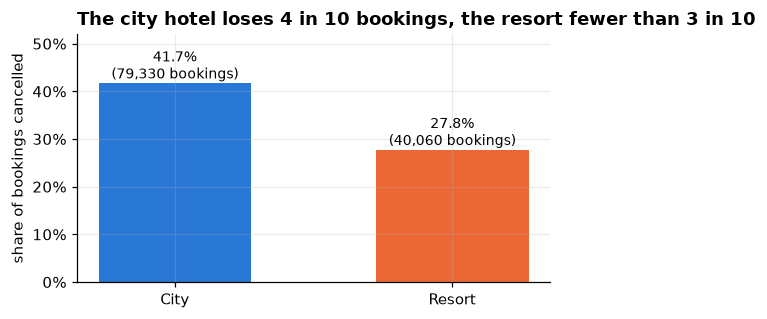

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3))
cancel_rate_by_hotel = bookings.groupby("hotel").IsCanceled.mean().reindex(["City", "Resort"])
bookings_per_hotel = bookings.hotel.value_counts()
bars = ax.bar(cancel_rate_by_hotel.index, cancel_rate_by_hotel.values,
              color=[HOTEL_COLOR[h] for h in cancel_rate_by_hotel.index], width=0.55)
for bar, hotel in zip(bars, cancel_rate_by_hotel.index):
    ax.annotate(f"{cancel_rate_by_hotel[hotel]:.1%}\n({bookings_per_hotel[hotel]:,} bookings)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 0.52)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_title("The city hotel loses 4 in 10 bookings, the resort fewer than 3 in 10")
ax.set_ylabel("share of bookings cancelled")
plt.show()


## 1.2 Lead time: the single strongest signal

Lead time is the number of days between making the booking and arrival. Intuitively, a
booking made a year ahead has far more opportunity to fall through than one made
yesterday - and the data agrees. I split lead time into ten equal-sized groups (deciles)
and look at the cancellation rate in each.

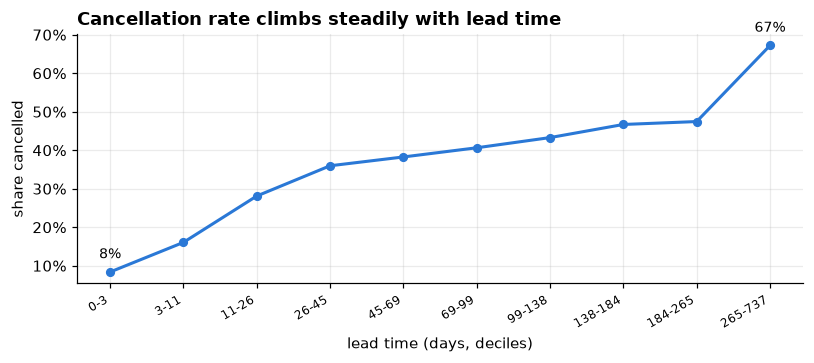

Median lead time: 69 days (a fact I will return to when judging the weather data)


In [6]:
lead_time_deciles = pd.qcut(bookings.LeadTime, 10, duplicates="drop")
cancel_rate_by_lead_time = bookings.groupby(lead_time_deciles, observed=True).IsCanceled.mean()
decile_labels = [f"{int(interval.left)}-{int(interval.right)}"
                 for interval in cancel_rate_by_lead_time.index]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(range(len(cancel_rate_by_lead_time)), cancel_rate_by_lead_time.values,
        color=BLUE, lw=2, marker="o", ms=5)
for i in (0, len(cancel_rate_by_lead_time) - 1):
    ax.annotate(f"{cancel_rate_by_lead_time.iloc[i]:.0%}", (i, cancel_rate_by_lead_time.iloc[i]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
ax.set_xticks(range(len(cancel_rate_by_lead_time)), decile_labels,
              rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_title("Cancellation rate climbs steadily with lead time")
ax.set_xlabel("lead time (days, deciles)")
ax.set_ylabel("share cancelled")
plt.show()
print(f"Median lead time: {bookings.LeadTime.median():.0f} days "
      f"(a fact I will return to when judging the weather data)")


## 1.3 Market segment and deposit type

Two more strong, business-meaningful drivers. The deposit result looks paradoxical -
**non-refundable bookings cancel 99% of the time** - so it deserves a closer look rather
than blind acceptance.

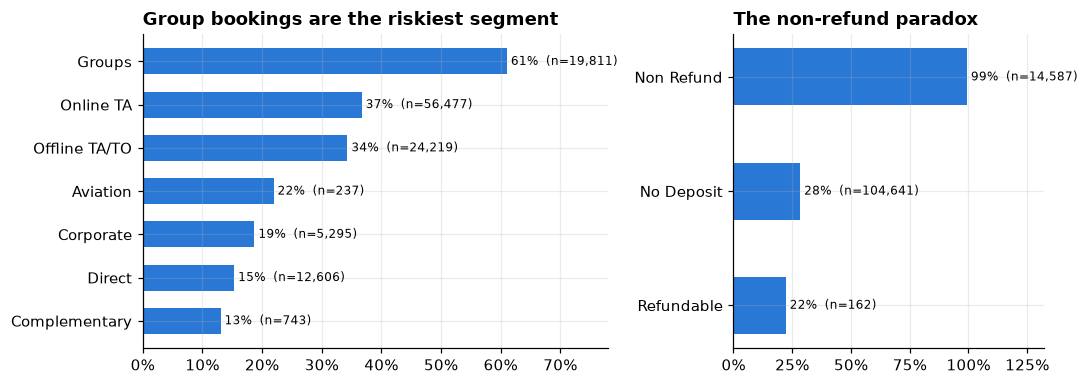

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [3, 2]})

segment_stats = (bookings.assign(segment=bookings.MarketSegment.str.strip())
                 .groupby("segment").IsCanceled.agg(["mean", "count"])
                 .query("count >= 100").sort_values("mean"))
axes[0].barh(segment_stats.index, segment_stats["mean"], color=BLUE, height=0.6)
for y, (rate, n) in enumerate(zip(segment_stats["mean"], segment_stats["count"])):
    axes[0].annotate(f" {rate:.0%}  (n={n:,})", (rate, y), va="center", fontsize=8)
axes[0].set_title("Group bookings are the riskiest segment")
axes[0].set_xlim(0, 0.78)
axes[0].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

deposit_stats = (bookings.assign(deposit=bookings.DepositType.str.strip())
                 .groupby("deposit").IsCanceled.agg(["mean", "count"]).sort_values("mean"))
axes[1].barh(deposit_stats.index, deposit_stats["mean"], color=BLUE, height=0.5)
for y, (rate, n) in enumerate(zip(deposit_stats["mean"], deposit_stats["count"])):
    axes[1].annotate(f" {rate:.0%}  (n={n:,})", (rate, y), va="center", fontsize=8)
axes[1].set_title("The non-refund paradox")
axes[1].set_xlim(0, 1.32)
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.show()


**Why would customers who paid a non-refundable deposit cancel 99% of the time?**
The payments log (Part 2) confirms these deposits really were charged, so it is not a
data error. This is a known quirk of the underlying dataset: the original authors explain
that these bookings are dominated by bulk reservations from particular agents and
markets - often speculative bookings made with no firm intention to stay (Antonio,
Almeida & Nunes, 2019). The practical point for me: `DepositType` is a genuinely
predictive booking-time feature, but it reflects *how* the booking was made, not the
customer's commitment.

## 1.4 Bookings over time

Both the volume and the cancellation rate drift across the two years - the city hotel
grows, and its cancellation rate creeps upward. This matters for how I test models: a
deployed model predicts the *future*, so in Part 3 I test on a later period than I train
on, instead of a random split.

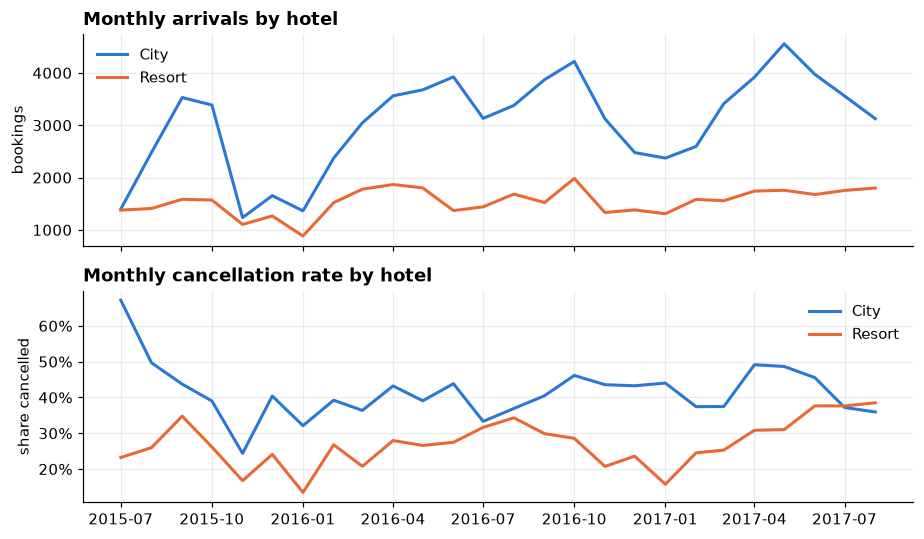

In [8]:
MONTH_NUMBER = {month: i for i, month in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"], 1)}
bookings["arrival_date"] = pd.to_datetime(dict(
    year=bookings.ArrivalDateYear,
    month=bookings.ArrivalDateMonth.map(MONTH_NUMBER),
    day=bookings.ArrivalDateDayOfMonth))
bookings["booking_date"] = bookings.arrival_date - pd.to_timedelta(bookings.LeadTime, unit="D")

monthly = (bookings.set_index("arrival_date")
           .groupby([pd.Grouper(freq="MS"), "hotel"]).IsCanceled
           .agg(n="size", rate="mean").reset_index())

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5), sharex=True)
for hotel, hotel_monthly in monthly.groupby("hotel"):
    axes[0].plot(hotel_monthly.arrival_date, hotel_monthly.n,
                 color=HOTEL_COLOR[hotel], lw=2, label=hotel)
    axes[1].plot(hotel_monthly.arrival_date, hotel_monthly.rate,
                 color=HOTEL_COLOR[hotel], lw=2, label=hotel)
axes[0].set_title("Monthly arrivals by hotel")
axes[0].set_ylabel("bookings")
axes[0].legend(frameon=False)
axes[1].set_title("Monthly cancellation rate by hotel")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].set_ylabel("share cancelled")
axes[1].legend(frameon=False)
plt.show()


## 1.5 EDA takeaways

* ~37% of bookings cancel; the city hotel (42%) more than the resort (28%).
* **Lead time** is strongly related to cancellation: 12% for last-minute bookings,
  rising steadily to ~57% for bookings made 6+ months ahead.
* **Deposit type**: Non Refund bookings cancel 99% of the time (see the note above).
* **Market segment**: Groups cancel 61%; Direct and Corporate bookings only ~15-19%.
* Volume and cancellation rates drift over time, so testing must respect time order.
* Data-quality problems spotted along the way (padded strings, disguised NULLs,
  impossible ages, leaky columns) are inventoried and fixed in Part 2.

## 1.6 A non-ML baseline heuristic

Any model I build should beat a rule a hotel manager could implement in a spreadsheet -
otherwise the model is not worth deploying. From the two strongest signals above:

> **Flag a booking as "will cancel" if the deposit type is Non Refund, or the lead time
> is over 100 days.**

100 days is roughly where the curve in 1.2 passes a 45% cancellation rate. I also make a
*graded* version (`heuristic_score`) that simply orders bookings by lead time with all
Non-Refund bookings on top, so the heuristic can also be compared with the models on
ranking quality later. Both get their proper evaluation on held-out data in Part 4;
defining them now, before any modelling, keeps that comparison fair.

In [9]:
LEAD_TIME_RULE_DAYS = 100   # from the decile chart in 1.2

def heuristic_flag(table: pd.DataFrame) -> pd.Series:
    """Binary rule: Non-Refund deposit or long lead time -> predict cancel."""
    is_non_refund = table.DepositType.str.strip() == "Non Refund"
    is_long_lead = table.LeadTime > LEAD_TIME_RULE_DAYS
    return (is_non_refund | is_long_lead).astype(int)

def heuristic_score(table: pd.DataFrame) -> pd.Series:
    """Graded version for ranking: lead time, with Non-Refund bookings forced on top."""
    is_non_refund = table.DepositType.str.strip() == "Non Refund"
    return table.LeadTime + 1000 * is_non_refund

flagged = heuristic_flag(bookings)
print(f"Heuristic flags {flagged.mean():.1%} of all bookings")
print(f"In-sample precision {bookings.IsCanceled[flagged == 1].mean():.1%}, "
      f"recall {flagged[bookings.IsCanceled == 1].mean():.1%} "
      f"(proper out-of-time evaluation follows in Part 4)")


Heuristic flags 42.6% of all bookings
In-sample precision 54.4%, recall 62.6% (proper out-of-time evaluation follows in Part 4)


# Part 2 - Data cleaning and feature engineering

## 2.1 Inventory of data-quality issues

Everything below was *discovered* (the checks are in the cells that follow), not assumed:

| # | Issue | Where | Fix |
|---|-------|-------|-----|
| 1 | Categorical values padded with spaces (e.g. `"BB       "`) | H1/H2: Meal, DepositType, room types, Agent, Company | strip whitespace on all string columns |
| 2 | Missing values disguised as the *string* `"NULL"` | Agent (~16k), Company (~112k) | convert to real missing; encode as `has_agent`/`has_company` flags |
| 3 | `Children` has 4 NaN | H1/H2 | fill with 0 (a missing count of children means none were recorded) |
| 4 | `Meal = "Undefined"` (1,169) | H1/H2 | map to `SC` - the source dataset's data dictionary defines Undefined and SC as the same thing (no meal package) |
| 5 | One negative ADR (-6.38) and one extreme ADR (5400) | H2 | negative -> 0 (a price cannot be negative); the 5400 is kept - it is a real booking |
| 6 | 180 bookings with 0 adults + 0 children + 0 babies | H1/H2 | dropped - a room with no occupants is not a valid stay |
| 7 | Duplicate guest rows (1,068 ids appear twice: UPPERCASE name + missing age) | Guests | deduplicate keeping the most complete row per guest |
| 8 | Impossible ages: -1 (234), >100 (325), NaN (1,587) | Guests | treat as missing |
| 9 | Country coded inconsistently: ISO-3 mostly, but `CN`/`cn` for China | Guests + H1/H2 | normalise to upper-case ISO-3 (`CN -> CHN`) |
| 10 | Payment timestamps in `dd/mm/yyyy` (other files use ISO) | Payments | parse with an explicit format |
| 11 | Weather dates in *mixed* formats, location spelled 6 ways | Weather | shown in 2.4 - the file is excluded on more fundamental grounds |
| 12 | **Leakage columns** - values that only exist after the outcome | several | the audit in 2.6 drops them with reasons |

In [10]:
bookings_clean = bookings.copy()

# (1) strip padding from every string column
string_columns = [c for c in bookings_clean.columns
                  if bookings_clean[c].dtype == object
                  or str(bookings_clean[c].dtype) in ("str", "string")]
for column in string_columns:
    bookings_clean[column] = bookings_clean[column].str.strip()

# (2) "NULL" strings -> real missing values
n_null_agents = bookings_clean.Agent.eq("NULL").sum()
n_null_companies = bookings_clean.Company.eq("NULL").sum()
bookings_clean[["Agent", "Company"]] = bookings_clean[["Agent", "Company"]].replace("NULL", pd.NA)

# (3) missing Children -> 0
bookings_clean["Children"] = bookings_clean.Children.fillna(0).astype(int)

# (4) Undefined meal means the same as SC (no meal package)
n_undefined_meals = bookings_clean.Meal.eq("Undefined").sum()
bookings_clean["Meal"] = bookings_clean.Meal.replace("Undefined", "SC")

# (5) a price cannot be negative
n_negative_prices = (bookings_clean.ADR < 0).sum()
bookings_clean.loc[bookings_clean.ADR < 0, "ADR"] = 0.0

# (6) bookings with nobody travelling are not valid stays
total_occupants = bookings_clean.Adults + bookings_clean.Children + bookings_clean.Babies
no_occupants = total_occupants == 0
bookings_clean = bookings_clean[~no_occupants].copy()

# (9) country codes: CN/cn -> CHN, everything upper-case
bookings_clean["Country"] = bookings_clean.Country.str.upper().replace("CN", "CHN")

print(f"NULL-string agents: {n_null_agents:,} | NULL-string companies: {n_null_companies:,}")
print(f"Undefined meals remapped: {n_undefined_meals:,} | negative prices fixed: {n_negative_prices}")
print(f"Zero-occupant bookings dropped: {no_occupants.sum()} -> {len(bookings_clean):,} bookings remain")


NULL-string agents: 16,340 | NULL-string companies: 112,593
Undefined meals remapped: 1,169 | negative prices fixed: 1
Zero-occupant bookings dropped: 180 -> 119,210 bookings remain


## 2.2 Cleaning the guest profiles

The duplicates here are not identical rows: each duplicated guest id has one normal row
and one with an UPPER-CASE name and a missing age (a classic double-entry artefact).
Sorting so the most complete row comes first, then keeping that one, resolves all of them
without losing information.

In [11]:
ADULT_AGE_MIN, ADULT_AGE_MAX = 16, 100   # plausible range for a booking guest

guests_clean = guests.copy()
for column in ["name", "country", "email", "notes"]:
    guests_clean[column] = guests_clean[column].str.strip()

n_duplicate_ids = guests_clean.guest_id.duplicated().sum()
guests_clean = (guests_clean
                .assign(n_missing=guests_clean.isna().sum(axis=1))
                .sort_values(["guest_id", "n_missing"])
                .drop_duplicates("guest_id", keep="first")
                .drop(columns="n_missing"))

impossible_age = (guests_clean.age < ADULT_AGE_MIN) | (guests_clean.age > ADULT_AGE_MAX)
print(f"Duplicate guest ids resolved: {n_duplicate_ids:,}")
print(f"Impossible ages set to missing: {impossible_age.sum():,} "
      f"(range was {guests.age.min():.0f} to {guests.age.max():.0f})")
guests_clean.loc[impossible_age, "age"] = np.nan

guests_clean["country"] = guests_clean.country.str.upper().replace("CN", "CHN")
print(f"Guests after cleaning: {len(guests_clean):,} | every booking has a guest profile: "
      f"{bookings_clean.GuestID.isin(guests_clean.guest_id).all()}")


Duplicate guest ids resolved: 1,068
Impossible ages set to missing: 564 (range was -1 to 999)
Guests after cleaning: 106,828 | every booking has a guest profile: True


### The `notes` column is a leak - here is the proof

Some notes say things like *"Has cancelled a previous reservation"*, and bookings by
guests with such notes cancel 75% of the time versus 34% for everyone else. Tempting
feature! But the notes have **no timestamp**, so I checked *when* they could have been
written: **6,511 guests with a cancellation note have exactly one booking in the entire
dataset** - there is no "previous reservation" for the note to refer to. For 76% of them,
that single booking is the one that got cancelled. So the note describes the very outcome
we are trying to predict: the profile text was written (or updated) *after* the outcome.
Using it would leak the future into the model, so `notes` is excluded. The honest
replacement is to *compute* each guest's real cancellation history from the booking
tables, using only what was known before the booking date - done in 2.5.

In [12]:
note_mentions_cancel = (guests_clean.set_index("guest_id")
                        .notes.str.lower().str.contains("cancel", na=False))
bookings_per_guest = bookings_clean.groupby("GuestID").agg(
    n_bookings=("BookingID", "count"), n_cancelled=("IsCanceled", "sum"))
bookings_per_guest["has_cancel_note"] = bookings_per_guest.index.map(note_mentions_cancel)

booking_has_note = bookings_clean.GuestID.map(note_mentions_cancel)
print("Cancellation rate by presence of a cancellation-mentioning note:")
print(bookings_clean.groupby(booking_has_note).IsCanceled.agg(rate="mean", n="count").round(3), "\n")

single_booking_guests = bookings_per_guest[bookings_per_guest.n_bookings == 1]
noted = single_booking_guests[single_booking_guests.has_cancel_note]
print(f"Guests with a cancellation note but only ONE booking ever: {len(noted):,}")
print(f"...whose single booking was cancelled: {noted.n_cancelled.gt(0).mean():.1%} "
      f"(vs {single_booking_guests.n_cancelled.gt(0).mean():.1%} across all single-booking guests)")
print("=> the notes were written after the fact: excluded as target leakage")


Cancellation rate by presence of a cancellation-mentioning note:
          rate       n
GuestID               
False    0.344  111310
True     0.754    7900 

Guests with a cancellation note but only ONE booking ever: 6,508
...whose single booking was cancelled: 75.7% (vs 36.6% across all single-booking guests)
=> the notes were written after the fact: excluded as target leakage


## 2.3 Payment events: two usable signals, two leaks

The payment log has four event types, and for each I ask the same question: *does this
event exist at the moment the booking is made?*

* `deposit_authorised` and `card_declined` happen at/around booking time (every decline
  in the data occurs within 3 days of the booking date) - **usable**.
* `payment_received` is charged at the stay, so it exists *only* for bookings that were
  never cancelled - its presence is literally the answer (0% cancellation below).
* `refund_issued` happens *because of* a cancellation (100% cancellation) - the answer
  again.

The table below establishes this empirically rather than taking it on faith. One more
check: `deposit_authorised` turns out to be almost perfectly redundant with
`DepositType != "No Deposit"` (the payment log mirrors the same fact), so the only *new*
information kept is the **number of card declines** - genuinely predictive: bookings with
a declined card cancel 67% of the time versus 37% overall.

In [13]:
payments_clean = payments.copy()
payments_clean["event_time"] = pd.to_datetime(payments_clean.event_time, format="%d/%m/%Y %H:%M")

events_per_booking = payments_clean.pivot_table(
    index="booking_id", columns="event_type", values="amount", aggfunc="count").fillna(0)
payment_audit = (bookings_clean.set_index("BookingID")[["IsCanceled", "booking_date", "DepositType"]]
                 .join(events_per_booking))
payment_audit[events_per_booking.columns] = payment_audit[events_per_booking.columns].fillna(0)

audit_rows = []
for event_type in events_per_booking.columns:
    with_event = payment_audit[payment_audit[event_type] > 0]
    audit_rows.append({"event": event_type,
                       "bookings with event": len(with_event),
                       "cancellation rate when present": round(with_event.IsCanceled.mean(), 3)})
print(pd.DataFrame(audit_rows).to_string(index=False))
print(f"\nOverall cancellation rate: {bookings_clean.IsCanceled.mean():.3f}")

declines = payments_clean[payments_clean.event_type == "card_declined"].merge(
    bookings_clean[["BookingID", "booking_date"]], left_on="booking_id", right_on="BookingID")
days_after_booking = (declines.event_time - declines.booking_date).dt.days
print(f"\ncard_declined events occur {days_after_booking.min()}-{days_after_booking.max()} "
      f"days after booking")

print("\ndeposit_authorised vs DepositType (crosstab):")
print(pd.crosstab(payment_audit["deposit_authorised"] > 0, payment_audit.DepositType))

payment_features = (events_per_booking[["card_declined"]]
                    .rename(columns={"card_declined": "n_card_declined"}))


             event  bookings with event  cancellation rate when present
     card_declined                25125                           0.671
deposit_authorised                14312                           0.985
  payment_received                72715                           0.000
     refund_issued                   35                           1.000

Overall cancellation rate: 0.371

card_declined events occur 0-3 days after booking

deposit_authorised vs DepositType (crosstab):
DepositType         No Deposit  Non Refund  Refundable
deposit_authorised                                    
False                   104461         433           4
True                         0       14154         158


## 2.4 Weather: establishing that a source adds no value

The brief allows dropping a source *if you show how you established that*. I have two
independent reasons:

**1. The information does not exist at prediction time.** The median lead time is 69 days
and 75% of bookings are made more than two weeks ahead. Weather cannot be forecast beyond
about 10 days, so arrival-day weather is unknowable for the vast majority of bookings.
Training on it would give the model information it can never have in production.

**2. Even cheating, there is next to no signal.** As a test, I join arrival-day weather
anyway - as if we had a perfect forecast - and check whether it separates cancelled from
kept bookings. Rainfall tells us nothing. Temperature shows a mild gradient (33% to 40%
across thirds), but that is just the seasons in disguise: warm days are summer days, and
the arrival month already carries that information legitimately. So weather adds nothing
beyond features we already have.

The file is also the dirtiest of the five (mixed date formats, six spellings of two
locations, duplicate readings, a "maximum temperature" of 83.7°C) - documented below for
completeness, but the exclusion rests on the two arguments above, which no amount of
cleaning would fix.

In [14]:
weather_clean = weather.copy()
print("Location spellings found:", sorted(weather_clean.location.unique()))
is_iso_date = weather_clean.date.str.match(r"\d{4}-\d{2}-\d{2}")
print(f"Date formats: {is_iso_date.sum():,} ISO (yyyy-mm-dd) vs {(~is_iso_date).sum():,} dd/mm/yyyy")

weather_clean["location"] = weather_clean.location.str.strip().str.title()
weather_clean["date"] = pd.to_datetime(np.where(is_iso_date, weather_clean.date, pd.NA),
                                       errors="coerce")
weather_clean.loc[weather_clean.date.isna(), "date"] = pd.to_datetime(
    weather.date[~is_iso_date], format="%d/%m/%Y", errors="coerce")
n_duplicate_readings = weather_clean.duplicated(["date", "location"]).sum()
print(f"Duplicate (date, location) readings after normalising: {n_duplicate_readings}")
weather_clean = weather_clean.drop_duplicates(["date", "location"])

print(f"\n75% of bookings are made {bookings_clean.LeadTime.quantile(0.25):.0f}+ days ahead "
      f"(median {bookings_clean.LeadTime.median():.0f}) - far beyond any forecast horizon")

# --- the cheating test: join arrival-day weather as if we had a perfect forecast
from sklearn.metrics import roc_auc_score
HOTEL_LOCATION = {"City": "Lisbon", "Resort": "Algarve"}
with_weather = (bookings_clean.assign(location=bookings_clean.hotel.map(HOTEL_LOCATION))
                .merge(weather_clean, left_on=["arrival_date", "location"],
                       right_on=["date", "location"], how="left")
                .dropna(subset=["temp_max_c", "precip_mm"]))
print(f"\nBookings with arrival-day weather available: {len(with_weather):,}")
for column in ["temp_max_c", "precip_mm"]:
    thirds = pd.qcut(with_weather[column], 3, duplicates="drop")
    print(f"\nCancellation rate by {column} third:")
    print(with_weather.groupby(thirds, observed=True).IsCanceled.mean().round(3).to_string())
    auc = roc_auc_score(with_weather.IsCanceled, with_weather[column])
    print(f"ranking ability of {column} alone: {auc:.3f}  (0.5 = no better than random)")


Location spellings found: ['ALGARVE ', 'Algarve', 'LISBON ', 'Lisbon', 'algarve', 'lisbon']
Date formats: 1,482 ISO (yyyy-mm-dd) vs 197 dd/mm/yyyy
Duplicate (date, location) readings after normalising: 17

75% of bookings are made 18+ days ahead (median 69) - far beyond any forecast horizon



Bookings with arrival-day weather available: 116,307

Cancellation rate by temp_max_c third:
temp_max_c
(9.299000000000001, 20.5]    0.333
(20.5, 26.5]                 0.385
(26.5, 83.7]                 0.397
ranking ability of temp_max_c alone: 0.532  (0.5 = no better than random)

Cancellation rate by precip_mm third:
precip_mm
(-0.001, 16.2]    0.372
ranking ability of precip_mm alone: 0.496  (0.5 = no better than random)


## 2.5 Guest history features (time-aware)

What a repeat guest did *before* is legitimately knowable at booking time - the trick is
computing it without accidentally peeking at the future. For each booking I look at that
guest's *other* bookings and count:

* `prior_bookings` - bookings **made** before this one (earlier `booking_date`);
* `prior_cancellations` - prior bookings whose cancellation was already **known** before
  this booking was made. A cancellation becomes known on its `ReservationStatusDate`, so
  I compare that date (not the arrival date) against the current booking date;
* `prior_cancel_rate` - cancellations divided by *resolved* prior bookings
  (0 for first-time guests).

This is the honest version of what the leaky `notes` column pretended to offer. Only
about 10% of bookings come from repeat guests, so a simple loop over those guests is
fast enough.

In [15]:
bookings_clean["outcome_known_date"] = pd.to_datetime(bookings_clean.ReservationStatusDate)

n_prior_bookings = np.zeros(len(bookings_clean))
n_prior_cancellations = np.zeros(len(bookings_clean))
n_prior_resolved = np.zeros(len(bookings_clean))

row_position = {booking_id: i for i, booking_id in enumerate(bookings_clean.BookingID)}
repeat_guest_bookings = bookings_clean[bookings_clean.GuestID.duplicated(keep=False)]

for guest_id, guest_bookings in repeat_guest_bookings.groupby("GuestID"):
    booked_on = guest_bookings.booking_date.to_numpy()
    outcome_known_on = guest_bookings.outcome_known_date.to_numpy()
    was_cancelled = guest_bookings.IsCanceled.to_numpy()
    booking_ids = guest_bookings.BookingID.to_numpy()
    for i in range(len(guest_bookings)):
        position = row_position[booking_ids[i]]
        # strictly earlier, so a booking never counts itself
        n_prior_bookings[position] = (booked_on < booked_on[i]).sum()
        already_resolved = outcome_known_on < booked_on[i]
        n_prior_resolved[position] = already_resolved.sum()
        n_prior_cancellations[position] = (already_resolved & (was_cancelled == 1)).sum()

bookings_clean["prior_bookings"] = n_prior_bookings
bookings_clean["prior_cancellations"] = n_prior_cancellations
bookings_clean["prior_cancel_rate"] = np.where(
    n_prior_resolved > 0, n_prior_cancellations / np.maximum(n_prior_resolved, 1), 0.0)

is_repeat = bookings_clean.prior_bookings > 0
has_prior_cancellation = bookings_clean.prior_cancellations > 0
print(f"Bookings from guests with a prior booking: {is_repeat.sum():,} ({is_repeat.mean():.1%})")
print("\nCancellation rate by guest history (sanity check that the feature means something):")
history_group = pd.Series("first booking", index=bookings_clean.index)
history_group[is_repeat & ~has_prior_cancellation] = "prior bookings, never cancelled"
history_group[is_repeat & has_prior_cancellation] = "has a prior cancellation"
print(bookings_clean.groupby(history_group).IsCanceled.agg(rate="mean", n="count").round(3))


Bookings from guests with a prior booking: 12,448 (10.4%)

Cancellation rate by guest history (sanity check that the feature means something):
                                  rate       n
first booking                    0.368  106762
has a prior cancellation         0.848    4553
prior bookings, never cancelled  0.130    7895


## 2.6 The modelling table: joins and the leakage audit

**Joins.** Guests join 1-to-1 on `GuestID` (only the cleaned `age` survives - `name` and
`email` are identifiers, `notes` is leakage, and the guest's `country` duplicates the
booking's own `Country`). Payments aggregate to one row per booking (count of card
declines; no events = 0). Weather is excluded (2.4). Guest history comes from the booking
tables themselves (2.5).

**The audit.** Every original column is either kept or dropped with a reason. The
dropped ones:

| Column | Reason for dropping |
|--------|---------------------|
| `ReservationStatus`, `ReservationStatusDate` | they *are* the outcome |
| `AssignedRoomType` | assigned at check-in, after the prediction moment (`ReservedRoomType`, chosen at booking, is kept) |
| `BookingChanges` | counts edits made *after* booking |
| `DaysInWaitingList` | resolved between booking and confirmation - not knowable at the moment of booking |
| `Agent`, `Company` | hundreds of id levels would overfit; replaced by simple `has_agent` / `has_company` flags |
| `ArrivalDateYear`, `ArrivalDateWeekNumber`, `ArrivalDateDayOfMonth` | a year number cannot generalise to future years; the month captures the seasonal signal |
| guest `name`, `email`, `notes` | identifiers / proven leakage (2.2) |
| payments `payment_received`, `refund_issued` | mirror the outcome (2.3) |
| weather (whole file) | unknowable at booking time + no signal (2.4) |

In [16]:
model_table = (bookings_clean
    .merge(guests_clean[["guest_id", "age"]],
           left_on="GuestID", right_on="guest_id", how="left")
    .merge(payment_features, left_on="BookingID", right_index=True, how="left"))
model_table["n_card_declined"] = model_table.n_card_declined.fillna(0)
model_table["has_agent"] = bookings_clean.Agent.notna().astype(int).values
model_table["has_company"] = bookings_clean.Company.notna().astype(int).values
model_table["arrival_month"] = model_table.arrival_date.dt.month.astype(str)

NUMERIC_FEATURES = ["LeadTime", "StaysInWeekendNights", "StaysInWeekNights", "Adults",
                    "Children", "Babies", "ADR", "RequiredCarParkingSpaces",
                    "TotalOfSpecialRequests", "age", "n_card_declined", "has_agent",
                    "has_company", "prior_bookings", "prior_cancellations",
                    "prior_cancel_rate"]
CATEGORICAL_FEATURES = ["hotel", "Meal", "Country", "MarketSegment", "DistributionChannel",
                        "ReservedRoomType", "DepositType", "CustomerType", "arrival_month"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "IsCanceled"

model_table = (model_table[["BookingID", "GuestID", "arrival_date", "booking_date", TARGET]
               + ALL_FEATURES].set_index("BookingID"))
for column in CATEGORICAL_FEATURES:
    model_table[column] = model_table[column].astype("category")

print(f"Modelling table: {model_table.shape[0]:,} bookings, "
      f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")
print(f"Remaining missingness: only guest age "
      f"({model_table.age.isna().mean():.1%} missing - handled inside the model pipelines)")
model_table.head(3)


Modelling table: 119,210 bookings, 16 numeric + 9 categorical features
Remaining missingness: only guest age (1.5% missing - handled inside the model pipelines)


,GuestID,arrival_date,booking_date,IsCanceled,LeadTime,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,...,prior_cancel_rate,hotel,Meal,Country,MarketSegment,DistributionChannel,ReservedRoomType,DepositType,CustomerType,arrival_month
BookingID,,,,,,,,,,,,,,,,,,,,,
BKG0000011,G024920,2015-07-01,2014-07-24,0,342,0,0,2,0,0,...,0.0,Resort,BB,PRT,Direct,Direct,C,No Deposit,Transient,7
BKG0000001,G053764,2015-07-01,2013-06-24,0,737,0,0,2,0,0,...,0.0,Resort,BB,PRT,Direct,Direct,C,No Deposit,Transient,7
BKG0008205,G026272,2015-07-01,2015-06-24,0,7,0,1,1,0,0,...,0.0,Resort,BB,GBR,Direct,Direct,A,No Deposit,Transient,7


# Part 3 - Model building

## 3.1 Train/test split: hold out the future, not a random sample

A deployed model always predicts *future* bookings from *past* ones, and 1.4 showed that
booking behaviour drifts over the two years. So instead of a random split, I hold out the
**last six months of arrivals (from 1 March 2017)** as the test set and do not touch it
until Part 4. All tuning happens with cross-validation inside the training window only.

One detail worth stating: repeat guests appear on both sides of the split (~10% of
bookings). That is not cheating - it is exactly the real situation (a known guest books
again) - and the history features from 2.5 only ever use information from before each
booking.

## 3.2 Two model families

The assignment asks for at least two different families. I chose the two standard
starting points, both from scikit-learn:

* **Logistic regression** - the classic linear model for binary outcomes. It needs the
  features prepared first: fill missing ages with the median, put numeric features on a
  comparable scale, and one-hot encode the categorical ones (rare categories with fewer
  than 100 bookings are grouped together so they do not add noise).
* **Gradient-boosted trees** (`HistGradientBoostingClassifier`) - a different family
  entirely: it builds many small decision trees, each correcting the previous ones, and
  can pick up interactions between features (for example lead time mattering more in
  some segments). It handles missing ages and categorical features natively.

Each model lives inside a scikit-learn `Pipeline`, which chains the preparation steps and
the model into one object - so the exact same preparation is applied wherever the model
goes, including the Part 5 scoring script.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

TEST_PERIOD_START = pd.Timestamp("2017-03-01")   # last ~6 months of arrivals held out

train = model_table[model_table.arrival_date < TEST_PERIOD_START]
test = model_table[model_table.arrival_date >= TEST_PERIOD_START]
X_train, y_train = train[ALL_FEATURES], train[TARGET]
X_test, y_test = test[ALL_FEATURES], test[TARGET]
print(f"train: {len(train):,} bookings (arrivals Jul 2015 - Feb 2017), "
      f"cancellation rate {y_train.mean():.1%}")
print(f"test:  {len(test):,} bookings (arrivals Mar - Aug 2017), "
      f"cancellation rate {y_test.mean():.1%}")

cross_validation = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


train: 86,431 bookings (arrivals Jul 2015 - Feb 2017), cancellation rate 36.0%
test:  32,779 bookings (arrivals Mar - Aug 2017), cancellation rate 40.0%


In [18]:
# --- Model family 1: logistic regression -------------------------------------
RARE_CATEGORY_MIN_COUNT = 100   # categories rarer than this are grouped as "infrequent"

logistic_pipeline = Pipeline([
    ("prepare", ColumnTransformer([
        ("numeric", Pipeline([("fill_missing", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())]), NUMERIC_FEATURES),
        ("categorical", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                      min_frequency=RARE_CATEGORY_MIN_COUNT),
         CATEGORICAL_FEATURES),
    ])),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

# C controls regularisation strength (how much the coefficients are shrunk toward 0);
# class_weight="balanced" gives the rarer cancelled class more weight during fitting.
logistic_search = GridSearchCV(
    logistic_pipeline,
    param_grid={"model__C": [0.1, 1, 10],
                "model__class_weight": [None, "balanced"]},
    cv=cross_validation, scoring="roc_auc", n_jobs=-1)
logistic_search.fit(X_train, y_train)
print(f"best settings: {logistic_search.best_params_}")
print(f"cross-validated ROC-AUC on train: {logistic_search.best_score_:.3f}")


best settings: {'model__C': 1, 'model__class_weight': 'balanced'}
cross-validated ROC-AUC on train: 0.914


In [19]:
# --- Model family 2: gradient-boosted trees -----------------------------------
N_BOOSTING_ROUNDS = 300   # number of trees; fixed, only the settings below are tuned

# The trees need categories as numbers: OrdinalEncoder does that, and any category
# never seen in training becomes "missing", which this model handles gracefully.
boosted_pipeline = Pipeline([
    ("prepare", ColumnTransformer([
        ("categorical", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=np.nan), CATEGORICAL_FEATURES),
        ("numeric", "passthrough", NUMERIC_FEATURES),
    ])),
    ("model", HistGradientBoostingClassifier(
        max_iter=N_BOOSTING_ROUNDS,
        categorical_features=list(range(len(CATEGORICAL_FEATURES))),
        random_state=RANDOM_STATE)),
])

# learning_rate = how big a correction each tree makes; max_leaf_nodes = tree size
boosted_search = GridSearchCV(
    boosted_pipeline,
    param_grid={"model__learning_rate": [0.05, 0.1, 0.2],
                "model__max_leaf_nodes": [31, 63]},
    cv=cross_validation, scoring="roc_auc", n_jobs=-1)
boosted_search.fit(X_train, y_train)
print(f"best settings: {boosted_search.best_params_}")
print(f"cross-validated ROC-AUC on train: {boosted_search.best_score_:.3f}")


best settings: {'model__learning_rate': 0.05, 'model__max_leaf_nodes': 63}
cross-validated ROC-AUC on train: 0.956


## 3.3 What did the model learn - and does it match the EDA?

Before trusting a model I want to see that what drives its predictions is consistent
with what the data exploration showed. Logistic regression makes this easy: each feature
gets one coefficient, positive pushes a booking toward "will cancel", negative pushes
away.

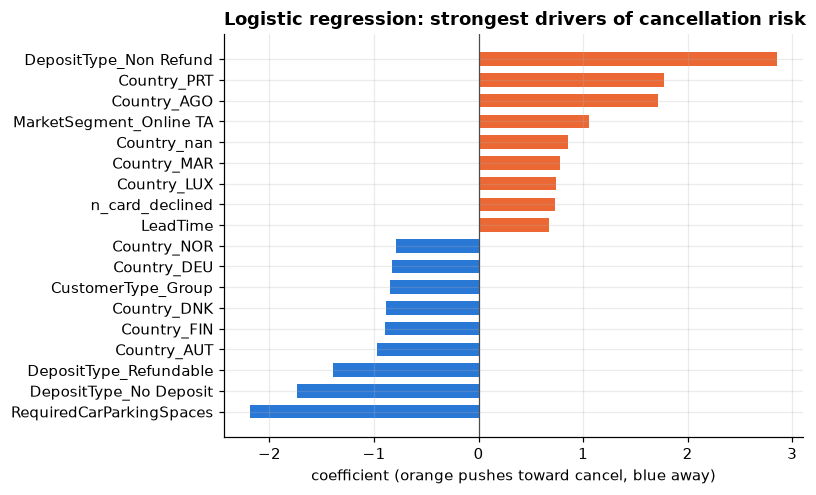

In [20]:
coefficients = pd.Series(
    logistic_search.best_estimator_["model"].coef_[0],
    index=logistic_search.best_estimator_["prepare"].get_feature_names_out())
coefficients.index = [name.removeprefix("numeric__").removeprefix("categorical__")
                      for name in coefficients.index]
strongest = pd.concat([coefficients.nlargest(9), coefficients.nsmallest(9)]).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(strongest.index, strongest.values,
        color=[ORANGE if value > 0 else BLUE for value in strongest.values], height=0.65)
ax.axvline(0, color="0.3", lw=0.8)
ax.set_title("Logistic regression: strongest drivers of cancellation risk")
ax.set_xlabel("coefficient (orange pushes toward cancel, blue away)")
plt.show()


This matches Part 1 well: **Non-Refund deposits**, certain **countries**, the
**Online TA segment**, **card declines** and **lead time** push risk up, while things
that signal an engaged, committed customer (parking space requested, special requests,
refundable or no-deposit bookings) push it down. Nothing here looks suspicious - if some
feature I barely understood had dominated, that would have sent me back to check for
leakage.

# Part 4 - Evaluation

## 4.1 The metrics, in plain words

Because only ~37% of bookings cancel, accuracy alone is misleading (always predicting
"no cancellation" scores 63%). So I judge the models on:

* **Accuracy** - share of all predictions that were right. Reported, but least useful.
* **Precision** - of the bookings we flagged as "will cancel", how many really did?
  Low precision means wasted interventions.
* **Recall** - of the bookings that really cancelled, how many did we flag?
  Low recall means missed cancellations.
* **F1** - a single score that balances precision and recall.
* **ROC-AUC** - the one ranking metric I use. Quoting the standard definition:

  > "The AUC of a classifier is equivalent to the probability that the classifier will
  > rank a randomly chosen positive instance higher than a randomly chosen negative
  > instance." - Fawcett (2006), *An introduction to ROC analysis*

  In our terms: pick one random cancelled booking and one random kept booking - ROC-AUC
  is the probability the model gives the cancelled one the higher risk score. 0.5 is
  coin-flipping, 1.0 is perfect. It is useful because it judges the *scores* directly,
  before any cut-off is chosen.

To turn a probability into a yes/no flag I use the natural cut-off of **0.5** - flag a
booking when the model thinks cancellation is more likely than not. Part 4.2 then checks
whether the probabilities themselves can be taken at face value.

In [21]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_curve)

DECISION_THRESHOLD = 0.5   # flag a booking when cancellation is more likely than not

lr_probabilities = logistic_search.best_estimator_.predict_proba(X_test)[:, 1]
hgb_probabilities = boosted_search.best_estimator_.predict_proba(X_test)[:, 1]
test_for_heuristic = test.assign(DepositType=test.DepositType.astype(str))
heuristic_flags = heuristic_flag(test_for_heuristic).values
heuristic_scores = heuristic_score(test_for_heuristic).values

def evaluate(name, flags, ranking_scores=None):
    """One results row: flag-based metrics, plus ROC-AUC if a graded score is given."""
    return {
        "model": name,
        "ROC-AUC": roc_auc_score(y_test, ranking_scores) if ranking_scores is not None else np.nan,
        "accuracy": accuracy_score(y_test, flags),
        "precision": precision_score(y_test, flags, zero_division=0),
        "recall": recall_score(y_test, flags),
        "F1": f1_score(y_test, flags),
    }

results = pd.DataFrame([
    evaluate("always 'no cancel'", np.zeros(len(y_test), dtype=int)),
    evaluate("heuristic (Part 1 rule)", heuristic_flags, heuristic_scores),
    evaluate("logistic regression", (lr_probabilities >= DECISION_THRESHOLD).astype(int),
             lr_probabilities),
    evaluate("gradient boosting", (hgb_probabilities >= DECISION_THRESHOLD).astype(int),
             hgb_probabilities),
]).set_index("model")
results.round(3)


,ROC-AUC,accuracy,precision,recall,F1
model,,,,,
always 'no cancel',NaN,0.600,0.000,0.000,0.000
heuristic (Part 1 rule),0.709,0.610,0.510,0.679,0.583
logistic regression,0.902,0.819,0.768,0.784,0.776
gradient boosting,0.904,0.821,0.818,0.712,0.761


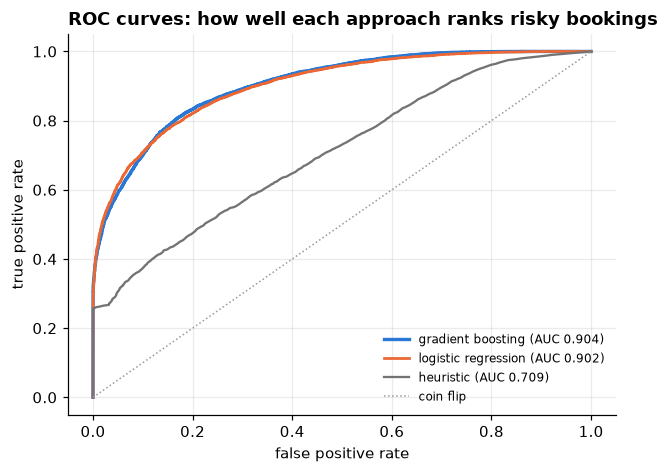

In [22]:
fig, ax = plt.subplots(figsize=(5.8, 4.4))
for name, scores, color, width in [
        ("gradient boosting", hgb_probabilities, BLUE, 2.2),
        ("logistic regression", lr_probabilities, ORANGE, 1.8),
        ("heuristic", heuristic_scores, "0.45", 1.5)]:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, scores)
    ax.plot(false_positive_rate, true_positive_rate, color=color, lw=width,
            label=f"{name} (AUC {roc_auc_score(y_test, scores):.3f})")
ax.plot([0, 1], [0, 1], ls=":", color="0.6", lw=1, label="coin flip")
ax.set_title("ROC curves: how well each approach ranks risky bookings")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()


## 4.2 Can the probabilities be taken at face value?

Part 5 outputs a probability, so it matters whether "70%" really means 70%. A simple
check: group the test bookings into risk bands by predicted probability and compare each
band's *actual* cancellation rate with what the model predicted.

In [23]:
RISK_BAND_EDGES = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

lr_auc = roc_auc_score(y_test, lr_probabilities)
hgb_auc = roc_auc_score(y_test, hgb_probabilities)
print(f"test ROC-AUC: logistic regression {lr_auc:.3f}, gradient boosting {hgb_auc:.3f}")
print("-> essentially tied, so I go forward with the simpler, interpretable model\n")
winner_name = "logistic regression"
winner_probabilities = lr_probabilities

risk_band = pd.cut(winner_probabilities, RISK_BAND_EDGES)
band_check = pd.DataFrame({"band": risk_band, "predicted": winner_probabilities,
                           "actually_cancelled": y_test.values})
band_summary = band_check.groupby("band", observed=True).agg(
    bookings=("predicted", "size"),
    mean_predicted_risk=("predicted", "mean"),
    actual_cancel_rate=("actually_cancelled", "mean")).round(3)
print(band_summary.to_string())
print("\nThe actual rate rises with every band, and the extreme bands - where the")
print("hotel would actually act - are accurate. The middle bands run a little high")
print("because training weighted the rarer cancelled class more heavily")
print("(class_weight='balanced'); worth remembering if the raw probabilities, rather")
print("than the ordering, are used for planning.")


test ROC-AUC: logistic regression 0.902, gradient boosting 0.904
-> essentially tied, so I go forward with the simpler, interpretable model

            bookings  mean_predicted_risk  actual_cancel_rate
band                                                         
(0.0, 0.2]     11212                0.079               0.059
(0.2, 0.4]      5814                0.294               0.228
(0.4, 0.6]      4356                0.495               0.407
(0.6, 0.8]      3497                0.698               0.595
(0.8, 1.0]      7900                0.949               0.922

The actual rate rises with every band, and the extreme bands - where the
hotel would actually act - are accurate. The middle bands run a little high
because training weighted the rarer cancelled class more heavily
(class_weight='balanced'); worth remembering if the raw probabilities, rather
than the ordering, are used for planning.


In [24]:
# What acting on the flags would have meant for the hotel over the test period
flags = (winner_probabilities >= DECISION_THRESHOLD).astype(int)
caught = int(((flags == 1) & (y_test == 1)).sum())
false_alarms = int(((flags == 1) & (y_test == 0)).sum())
missed = int(((flags == 0) & (y_test == 1)).sum())

print(f"Test period (Mar-Aug 2017): {len(y_test):,} bookings, {int(y_test.sum()):,} cancelled")
print(f"At the {DECISION_THRESHOLD:.0%} threshold the model flags {int(flags.sum()):,} bookings:")
print(f"  {caught:,} correctly flagged cancellations "
      f"(caught {caught / (caught + missed):.0%} of all cancellations)")
print(f"  {false_alarms:,} false alarms "
      f"({false_alarms / max(caught + false_alarms, 1):.0%} of flags)")
print(f"  {missed:,} cancellations missed")
print(f"\nThe Part 1 heuristic on the same bookings: "
      f"precision {y_test[heuristic_flags == 1].mean():.0%}, "
      f"recall {heuristic_flags[y_test == 1].mean():.0%}")


Test period (Mar-Aug 2017): 32,779 bookings, 13,127 cancelled
At the 50% threshold the model flags 13,400 bookings:
  10,291 correctly flagged cancellations (caught 78% of all cancellations)
  3,109 false alarms (23% of flags)
  2,836 cancellations missed

The Part 1 heuristic on the same bookings: precision 51%, recall 68%


## 4.3 What the comparison tells us

* **Both models clearly beat the heuristic** (ROC-AUC ~0.90 vs 0.71; about three quarters
  of their flags are right vs half for the heuristic). The heuristic still catches two
  thirds of cancellations with two if-statements - which is exactly why it is a fair
  yardstick: a model that could not beat it would not be worth deploying.
* **The result I found most interesting:** in cross-validation the boosted trees looked
  clearly better (~0.95 vs ~0.91), but on the truly *future* test months the two models
  came out essentially equal. My reading: the trees partly memorised patterns specific to
  the training period, and those patterns did not carry into the future. This is exactly
  why the test set was time-based - a random split would have hidden it.
* Since the two are tied on the future data, I keep the **logistic regression**: it is
  simpler, I can read its coefficients directly (3.3), and its probabilities check out
  in the risk-band table. That is the model I ship in Part 5.
* Honest caveats: this is one six-month window at two hotels; the extreme Non-Refund
  behaviour comes from particular booking channels and could change abruptly if agent
  contracts change; and first-time guests are scored on booking attributes alone, since
  they have no history yet.

# Part 5 - Production

## 5.1 The scoring artefact

Once evaluation is done, I refit the chosen pipeline on **all** labelled data (keeping
the freshest six months out of the final model would just waste them) and save
everything the scoring script needs into `artifacts/`:

* `model.joblib` - the fitted pipeline (preparation + model in one object);
* `metadata.json` - feature lists, decision threshold, training window, versions;
* `guest_lookup.csv` - guest id -> cleaned age;
* `booking_history.csv` - per-booking history from which the scorer rebuilds
  `prior_bookings`, `prior_cancellations` and `prior_cancel_rate` for a returning
  guest, with the same time-aware logic as 2.5.

In [25]:
import json
import joblib
import sklearn
from pathlib import Path

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

winner_pipeline = (logistic_search.best_estimator_ if winner_name == "logistic regression"
                   else boosted_search.best_estimator_)
winner_pipeline.fit(model_table[ALL_FEATURES], model_table[TARGET])   # refit on all data
joblib.dump(winner_pipeline, artifact_dir / "model.joblib")

guests_clean[["guest_id", "age"]].to_csv(artifact_dir / "guest_lookup.csv", index=False)
bookings_clean[["BookingID", "GuestID", "booking_date", "IsCanceled",
                "outcome_known_date"]].to_csv(artifact_dir / "booking_history.csv", index=False)

metadata = {
    "model": winner_name,
    "threshold": DECISION_THRESHOLD,
    "num_features": NUMERIC_FEATURES,
    "cat_features": CATEGORICAL_FEATURES,
    "trained_on": f"arrivals {model_table.arrival_date.min():%Y-%m-%d} "
                  f"to {model_table.arrival_date.max():%Y-%m-%d}",
    "test_roc_auc": round(float(roc_auc_score(y_test, winner_probabilities)), 4),
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
}
(artifact_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=2))


{
  "model": "logistic regression",
  "threshold": 0.5,
  "num_features": [
    "LeadTime",
    "StaysInWeekendNights",
    "StaysInWeekNights",
    "Adults",
    "Children",
    "Babies",
    "ADR",
    "RequiredCarParkingSpaces",
    "TotalOfSpecialRequests",
    "age",
    "n_card_declined",
    "has_agent",
    "has_company",
    "prior_bookings",
    "prior_cancellations",
    "prior_cancel_rate"
  ],
  "cat_features": [
    "hotel",
    "Meal",
    "Country",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "DepositType",
    "CustomerType",
    "arrival_month"
  ],
  "trained_on": "arrivals 2015-07-01 to 2017-08-31",
  "test_roc_auc": 0.9021,
  "sklearn_version": "1.9.0",
  "random_state": 42
}


## 5.2 Scoring one new booking

`score_booking.py` (repository root) ingests a single JSON record containing only what
exists at booking time - the booking fields plus the guest's id - looks up the guest's
age and history from the artefact tables, builds the exact feature row the pipeline
expects, and prints the probability and decision. `booking.json` is a ready-to-run
sample. Note what the input *cannot* contain: no reservation status, no payment
outcomes, no weather - the production interface only accepts booking-time fields, so
the scorer physically cannot leak.

In [26]:
print(open("booking.json").read())
import sys
!{sys.executable} score_booking.py booking.json


{
  "guest_id": "G000239",
  "hotel": "City",
  "booking_date": "2017-09-10",
  "arrival_date": "2017-12-22",
  "adults": 2,
  "children": 0,
  "babies": 0,
  "meal": "BB",
  "country": "AUT",
  "market_segment": "Online TA",
  "distribution_channel": "TA/TO",
  "reserved_room_type": "A",
  "deposit_type": "No Deposit",
  "customer_type": "Transient",
  "adr": 96.5,
  "stays_in_weekend_nights": 2,
  "stays_in_week_nights": 3,
  "required_car_parking_spaces": 0,
  "total_of_special_requests": 1,
  "agent": 9,
  "company": null,
  "card_declines_so_far": 0
}



{
  "booking": {
    "guest_id": "G000239",
    "hotel": "City",
    "arrival_date": "2017-12-22",
    "lead_time_days": 103
  },
  "guest_history_used": {
    "prior_bookings": 6.0,
    "prior_cancellations": 6.0,
    "prior_cancel_rate": 1.0
  },
  "cancellation_probability": 0.9873,
  "threshold": 0.5,
  "decision": "FLAG - high cancellation risk"
}


## 5.3 What running this in production would involve

**Serving.** The scorer is a small stateless script plus two lookup tables, so it could
sit behind a simple HTTP endpoint called by the booking system when a reservation is
confirmed. Scores could also be refreshed nightly (useful because card declines arrive
in the first days after booking).

**Monitoring.** Three things to watch, from fastest-alerting to slowest:
1. *The inputs* - are the incoming bookings starting to look different from training
   (lead times, segment mix, unseen country codes)? A spike in unknown categories means
   the booking system changed its vocabulary.
2. *The scores* - is the average predicted risk drifting? That flags a problem before
   any outcome is known.
3. *The outcomes* - once bookings resolve (by arrival date), recompute precision, recall
   and ROC-AUC on a rolling window and compare with Part 4. This lags by roughly the
   lead time, which is why the first two matter.

**Retraining.** Behaviour drifted visibly within our own two years (1.4), so I would
retrain on a schedule (quarterly seems a reasonable start) or when monitoring degrades -
always validating on a held-out future window, exactly as in Part 3.

**Acting on predictions.** Cheap actions for medium risk (confirmation email), stronger
ones for high risk (deposit request or a phone call), and the summed probabilities can
size an overbooking buffer. Two cautions: never auto-cancel anyone based on a
prediction (a false positive would turn away a real guest), and keep a small untreated
control group - if the interventions themselves change guest behaviour, the next
training set would otherwise be contaminated.